In [1]:
# Import polars and set configurations
# *** do not try to open things without "head"***

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# File path to massive data
# Read in data

K562_PATH = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/outputs/FINAL_AVERAGE_SHAP_CACHE/K562_all-data.feather"
K562 = pl.read_ipc(K562_PATH)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


# Volcano Plot for RBFOX2 bound at pos 4

In [3]:
# For just K562, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true, and unique rMATS Event ID

filtered_K562 = (
    K562
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2") & (pl.col("has_RBP_KD_4"))
    )
    .unique(subset=["rMATS Event ID"])
)

filtered_K562.head(5)

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin

In [4]:
# Get rid of unneccessary columns 

columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_4",
    "Raw P-Val",
    "rMATS Event ID"
]

filtered_K562 = filtered_K562.select(columns_to_keep)

In [5]:
# Check

filtered_K562.select(pl.len())
filtered_K562.head()

RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,Raw P-Val,rMATS Event ID
str,str,f64,f64,bool,f64,i64
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.004,true,1.0,35330
"""RBFOX2""","""RBFOX2_KD-1""",0.003717,-0.114,true,0.000013,48222
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.017,true,1.0,52300
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.016,true,1.0,30187
"""RBFOX2""","""RBFOX2_KD-1""",0.0,-0.159,true,0.0,25632


In [6]:
# convert to Pandas df
df = filtered_K562.to_pandas()
df.head()

,RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,Raw P-Val,rMATS Event ID
0,RBFOX2,RBFOX2_KD-1,1.000000,-0.004,True,1.000000,35330
1,RBFOX2,RBFOX2_KD-1,0.003717,-0.114,True,0.000013,48222
2,RBFOX2,RBFOX2_KD-1,1.000000,0.017,True,1.000000,52300
3,RBFOX2,RBFOX2_KD-1,1.000000,-0.016,True,1.000000,30187
4,RBFOX2,RBFOX2_KD-1,0.000000,-0.159,True,0.000000,25632


In [7]:

df["FDR_safe"] = df["FDR"].replace(0, 1e-12)
df["neg_log10_FDR"] = -np.log10(df["FDR_safe"])

In [8]:
np.nanmax(df["neg_log10_FDR"].to_numpy())


12.0

In [9]:
# Colors

def assign_color(row):
    if row["FDR"] >= 0.05 or abs(row["DeltaPSI"]) < 0.05:
        return "gray"
    elif row["DeltaPSI"] >= 0.05:
        return "red"
    elif row["DeltaPSI"] <= -0.05:
        return "blue"
    else:
        return "gray"  # fallback

df["color"] = df.apply(assign_color, axis=1)

counts = df["color"].value_counts().to_dict()
num_points = len(df)

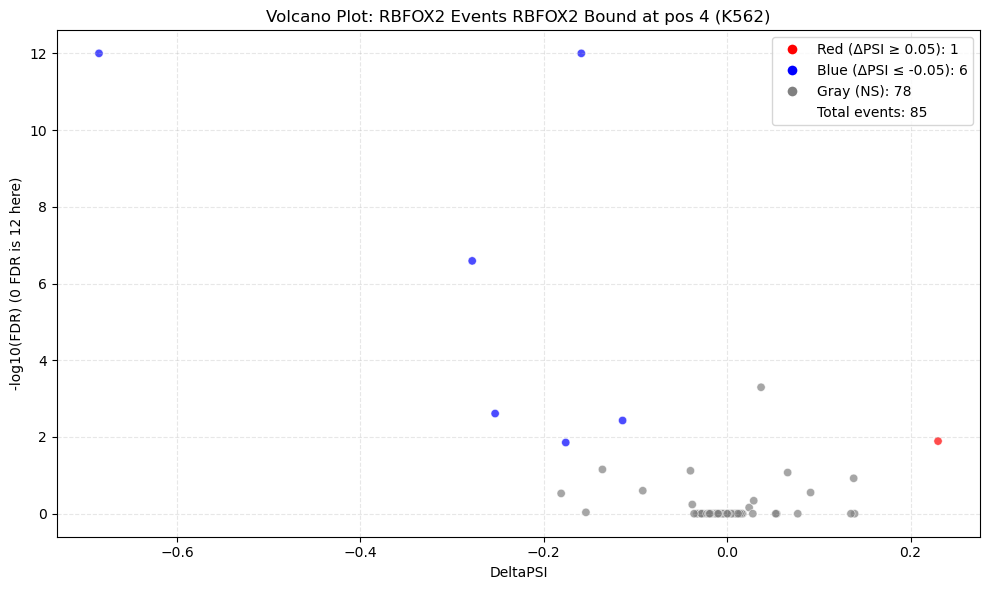

In [10]:
# Volcano plot for RBFOX2 KD in K562 events where RBFOX2 is bound at pos 4

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["DeltaPSI"],
    df["neg_log10_FDR"],
    c=df["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

# Reference lines
#plt.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1, label='FDR = 0.05')
#plt.axvline(0.05, linestyle='--', color='black', linewidth=1)
#plt.axvline(-0.05, linestyle='--', color='black', linewidth=1)

# Build custom legend entries
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="upper right")

# Labels
plt.xlabel("DeltaPSI")
plt.ylabel("-log10(FDR) (0 FDR is 12 here)")
plt.title("Volcano Plot: RBFOX2 Events RBFOX2 Bound at pos 4 (K562)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Volcano Plot for RBFOX2 bound at pos 4 and not pos 3

In [13]:
K562.head(3)

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin

In [11]:
# For just K562, get rows where RBP_KD_Target = RBFOX2, has_RBP_KD_4 = true, has_RBP_KD_3 = false, and unique rMATS Event ID
# K562.filter(pl.col("RBP_KD_Target")).select(pl.col("RBP_KD_Target") == "RBFOX2").collect()

more_filtered_K562 = (
    K562
    .filter(
        (pl.col("RBP_KD_Target") == "RBFOX2")
        & (pl.col("has_RBP_KD_4"))
        & (~pl.col("has_RBP_KD_3"))
    )
    .unique(subset=["rMATS Event ID"])
)

more_filtered_K562.head(5)

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin

In [12]:
# Check number of events

more_filtered_K562.select(pl.len())

len
u32
75


In [13]:
# Filter the dataframe for relavent columns

new_columns_to_keep = [
    "RBP_KD_Target",
    "Sample Name",
    "FDR",
    "DeltaPSI",
    "has_RBP_KD_4",
    "has_RBP_KD_3",
    "Raw P-Val",
    "rMATS Event ID"
]

more_filtered_K562 = more_filtered_K562.select(new_columns_to_keep)

# Check for correct columns
more_filtered_K562.head()

RBP_KD_Target,Sample Name,FDR,DeltaPSI,has_RBP_KD_4,has_RBP_KD_3,Raw P-Val,rMATS Event ID
str,str,f64,f64,bool,bool,f64,i64
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.01,true,false,0.685309,1613
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.001,true,false,1.0,4958
"""RBFOX2""","""RBFOX2_KD-1""",0.013946,-0.176,true,false,0.000103,19847
"""RBFOX2""","""RBFOX2_KD-1""",1.0,0.0,true,false,0.787292,54428
"""RBFOX2""","""RBFOX2_KD-1""",1.0,-0.006,true,false,1.0,31638


In [14]:
# Pandas and FDR

df_2 = more_filtered_K562.to_pandas()
df_2.head()

df_2["FDR_safe"] = df_2["FDR"].replace(0, 1e-12)
df_2["neg_log10_FDR"] = -np.log10(df_2["FDR_safe"])
np.nanmax(df_2["neg_log10_FDR"].to_numpy())

12.0

In [15]:
# Colors

df_2["color"] = df_2.apply(assign_color, axis=1)

counts = df_2["color"].value_counts().to_dict()
num_points = len(df_2)

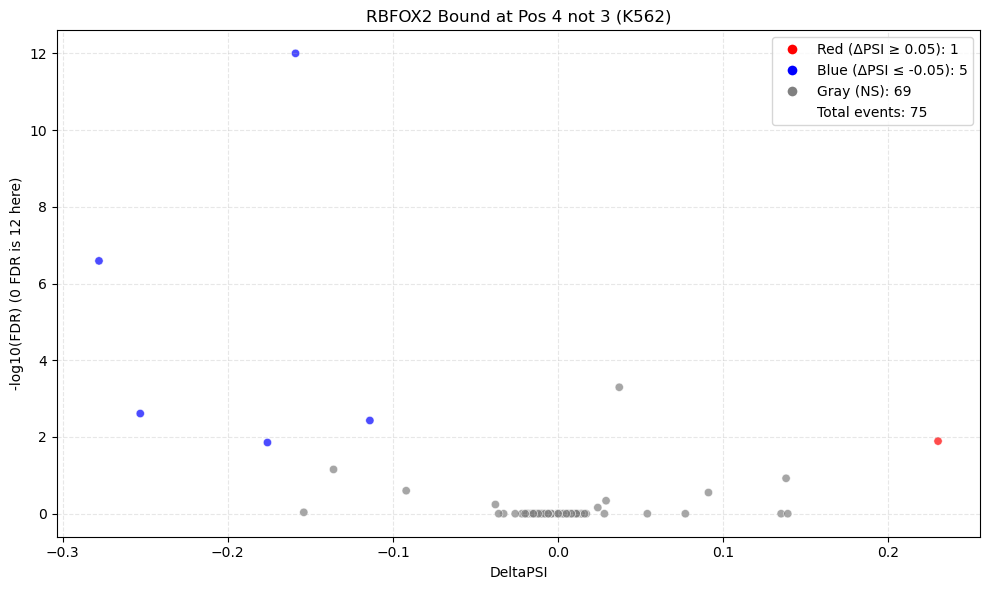

In [16]:
# Volcano plot

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_2["DeltaPSI"],
    df_2["neg_log10_FDR"],
    c=df_2["color"],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)

# Reference lines
#plt.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=1, label='FDR = 0.05')
#plt.axvline(0.05, linestyle='--', color='black', linewidth=1)
#plt.axvline(-0.05, linestyle='--', color='black', linewidth=1)

# Build custom legend entries
legend_labels = [
    f"Red (ΔPSI ≥ 0.05): {counts.get('red', 0)}",
    f"Blue (ΔPSI ≤ -0.05): {counts.get('blue', 0)}",
    f"Gray (NS): {counts.get('gray', 0)}",
    f"Total events: {num_points}"
]

# Create dummy handles for legend colors
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', label=legend_labels[0],
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[1],
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label=legend_labels[2],
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='w', label=legend_labels[3])  # total count (no color)
]

plt.legend(handles=handles, loc="upper right")

# Labels
plt.xlabel("DeltaPSI")
plt.ylabel("-log10(FDR) (0 FDR is 12 here)")
plt.title("RBFOX2 Bound at Pos 4 not 3 (K562)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()